In [1]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm


import seaborn as sns
import matplotlib.pyplot as plt


import importlib
import simres.expr
importlib.reload(simres.expr)
from simres.expr import *

import simres.operators
importlib.reload(simres.operators)
from simres.operators import *

In [2]:
enddate='20251231'
executor = AlphaExecutor(data_dir=f'../data/{enddate}',alpha_dir=f'../alphas/{enddate}')
executor.load_all_data()
executor.load_all_simres()
executor.load_all_alphas()

--- 正在初始化数据引擎 ---
已加载字段: [amount] | 形状: (1326, 2674)
已加载字段: [close] | 形状: (1326, 2674)
已加载字段: [csi_500_amount] | 形状: (1326, 2674)
已加载字段: [csi_500_close] | 形状: (1326, 2674)
已加载字段: [csi_500_high] | 形状: (1326, 2674)
已加载字段: [csi_500_low] | 形状: (1326, 2674)
已加载字段: [csi_500_open] | 形状: (1326, 2674)
已加载字段: [csi_500_volume] | 形状: (1326, 2674)
已加载字段: [csi_500_weight] | 形状: (1326, 2674)
已加载字段: [datestr] | 形状: (2674,)
已加载字段: [high] | 形状: (1326, 2674)
已加载字段: [industry] | 形状: (1326, 2674)
已加载字段: [low] | 形状: (1326, 2674)
已加载字段: [open] | 形状: (1326, 2674)
已加载字段: [stock_list] | 形状: (1326,)
已加载字段: [volume] | 形状: (1326, 2674)
已注入自定义算子: ['at_mask', 'at_nan2zero', 'at_zero2nan', 'cs_booksize', 'cs_group_quantile', 'cs_indneut', 'cs_rank', 'cs_zscore', 'ts_correlation', 'ts_delay', 'ts_delta', 'ts_fill', 'ts_kurtosis', 'ts_max', 'ts_mean', 'ts_min', 'ts_ols', 'ts_rank', 'ts_regression', 'ts_ret', 'ts_skewness', 'ts_std', 'ts_sum', 'ts_zscore']
--- 引擎就绪 ---

--- 正在初始化数据引擎 ---
success load alpha simres5000001

ts_mean(vwap-close,5)


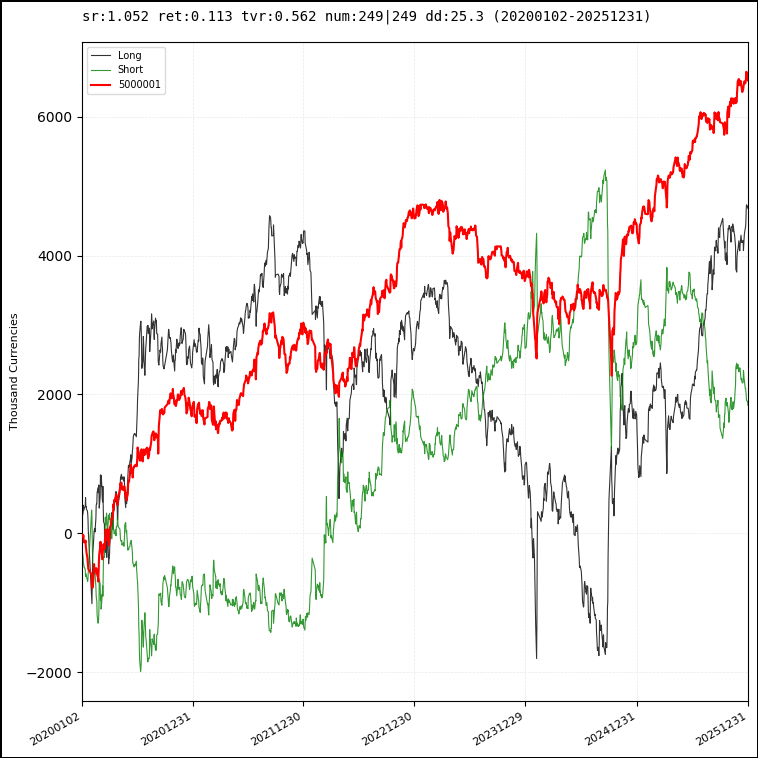

cs_rank(cs_rank(open)-cs_rank(ts_delay(close,1)))


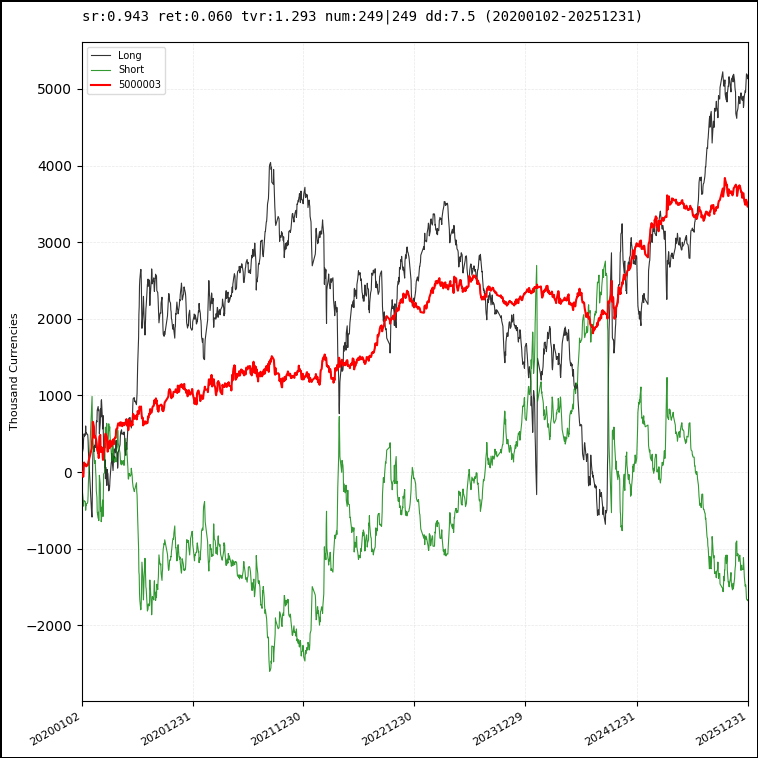

ts_correlation(ts_ret(low,1),ret1,3)


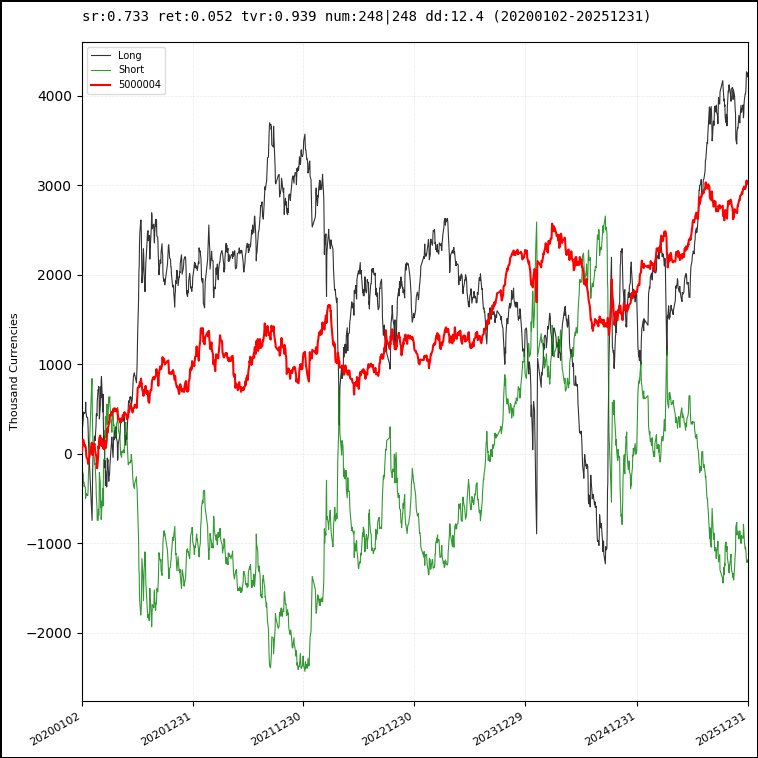

ts_ols(open/ts_delay(close,1),ts_delay(volume,1),10)[2]


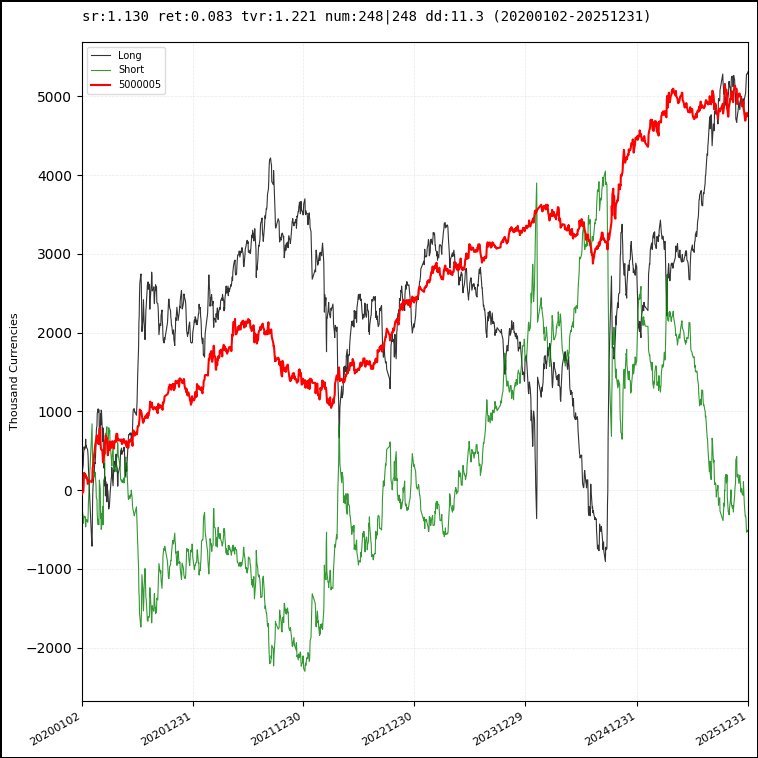

-ts_ols(close,ret1,10)[2]


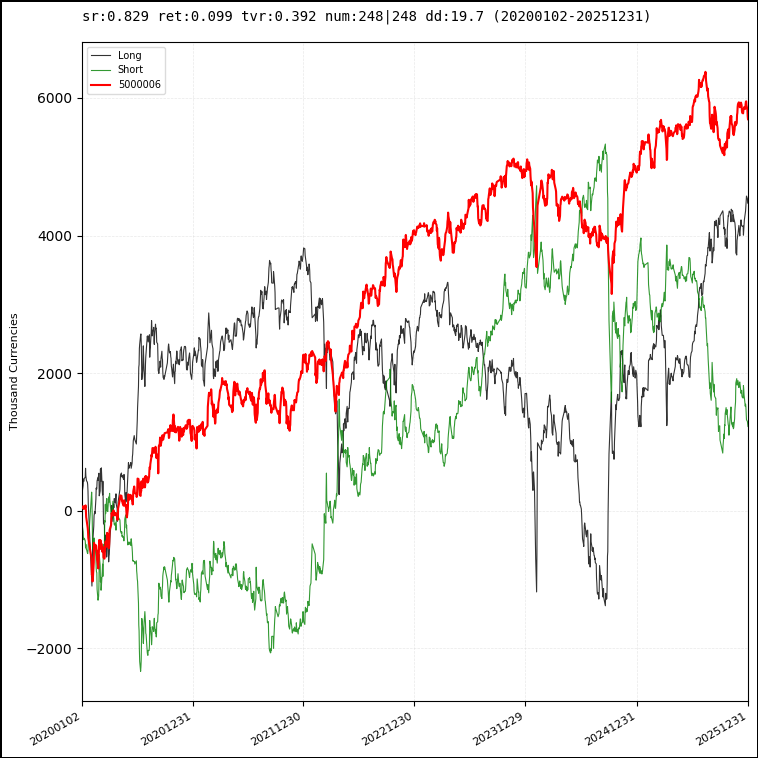

-ts_correlation(close,close/vwap-1,20)


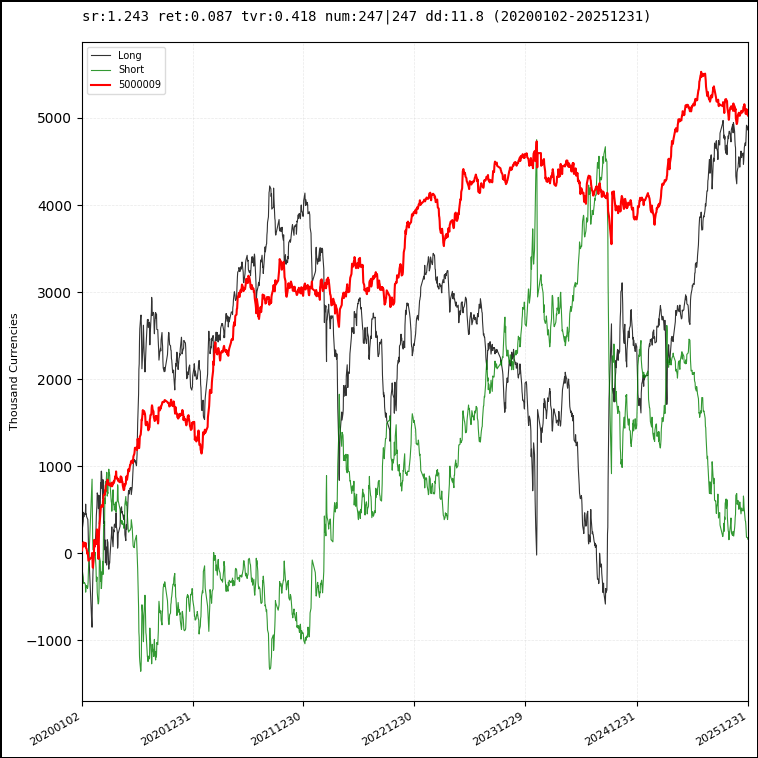

ts_correlation(cs_rank(ts_delay(volume,1)),cs_rank(ret1),5)


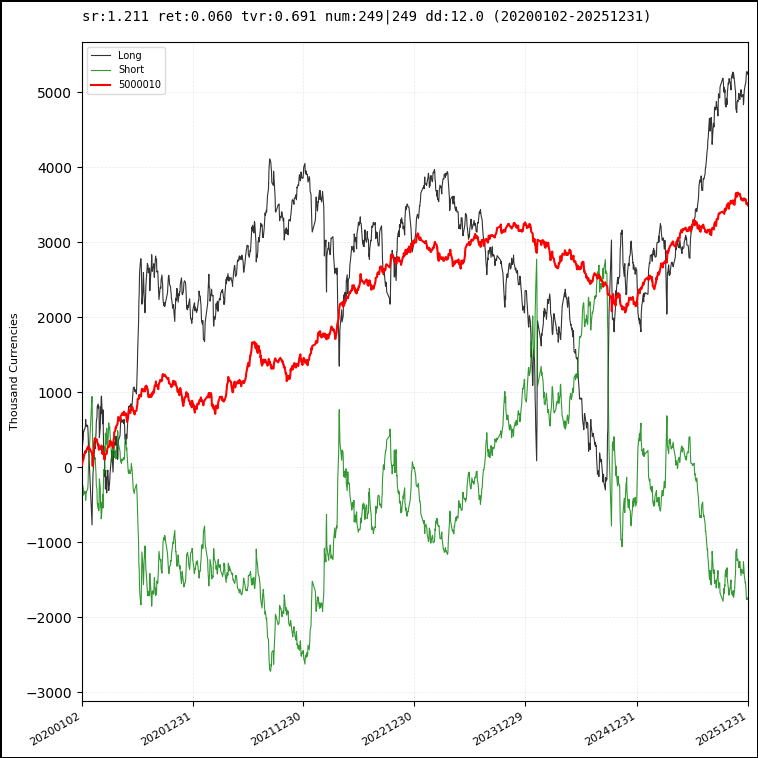

-close*volume*ts_zscore(ret1,2)


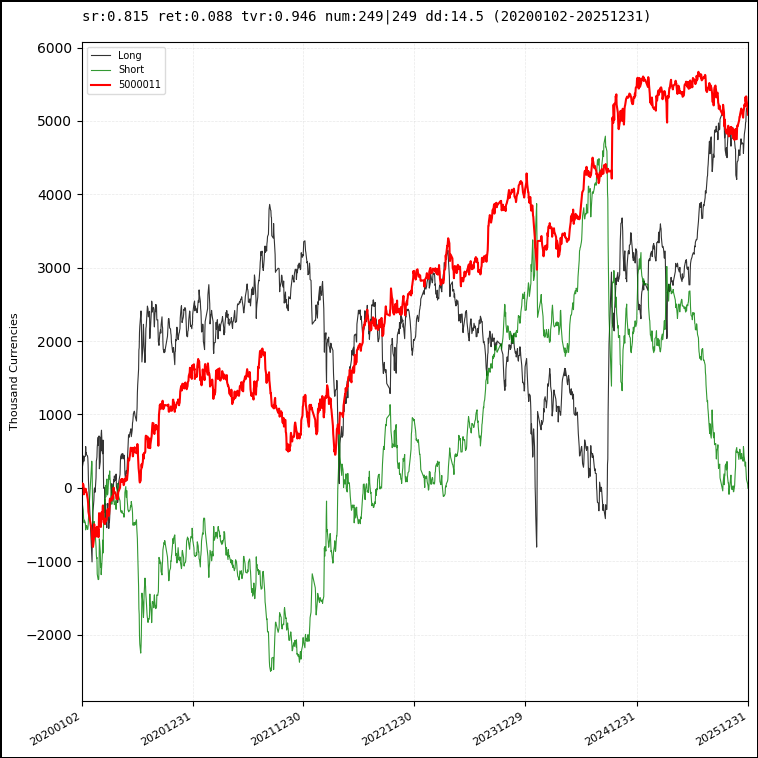

ts_correlation(ret1,csi_500_ret1,20)


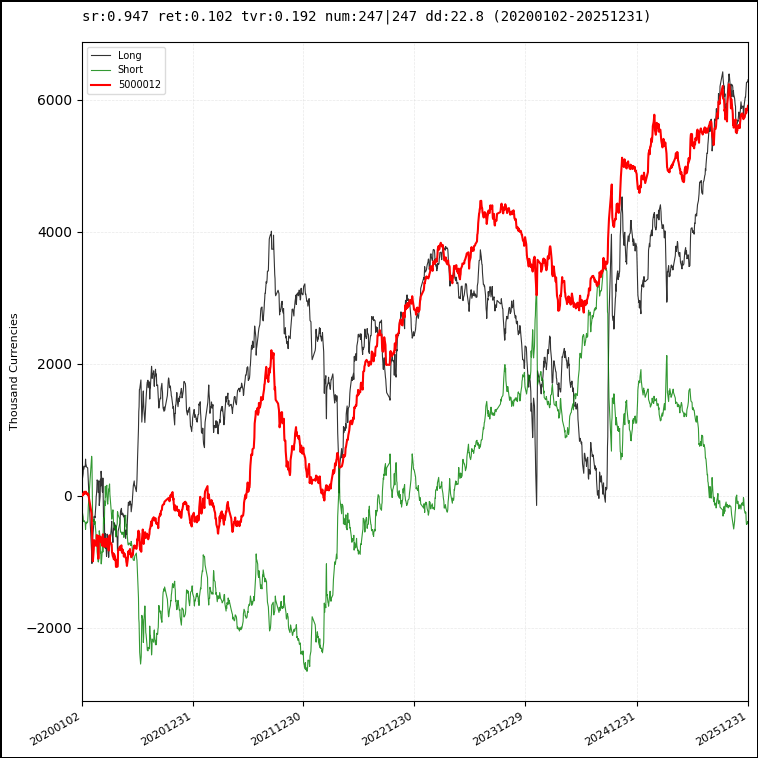

ts_ols(ret1,ts_delay(csi_500_ret1,1),5)[0]


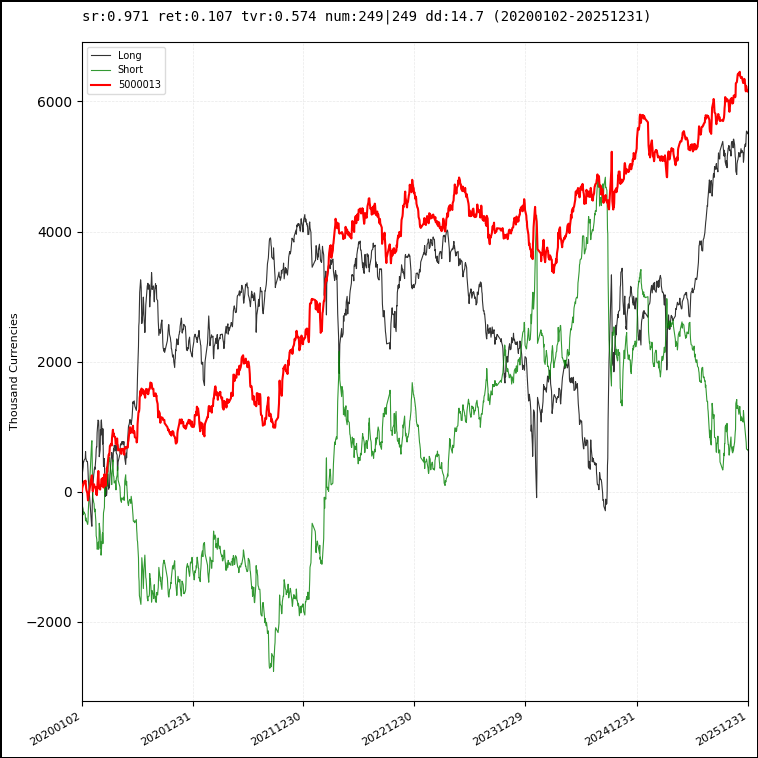

ts_ols(ret1,ts_delay(ret1,1),20)[0]


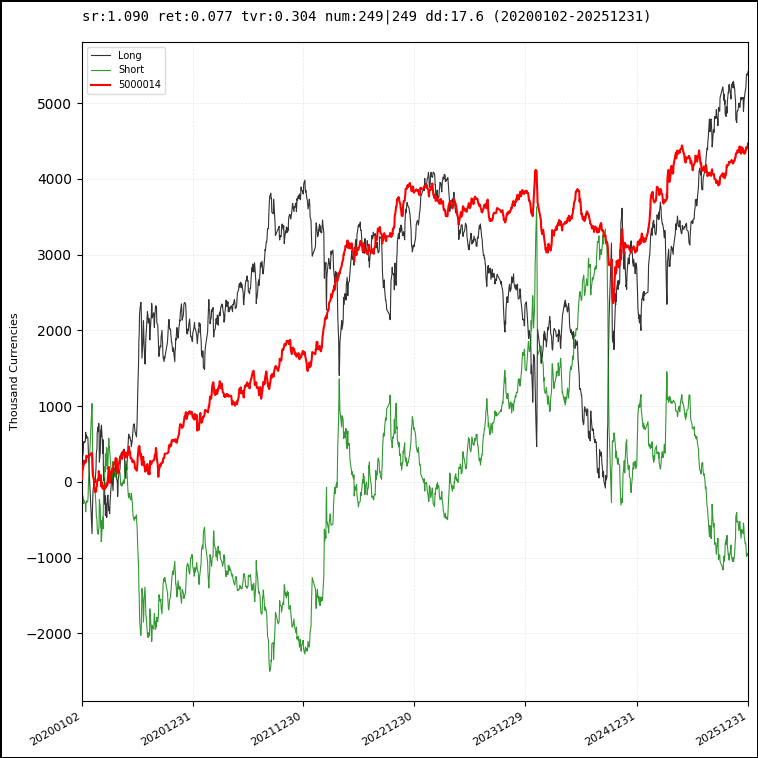

cs_indneut(high-close,cs_group_quantile(at_mask(close,ts_fill(csi_500_weight)>0),10))


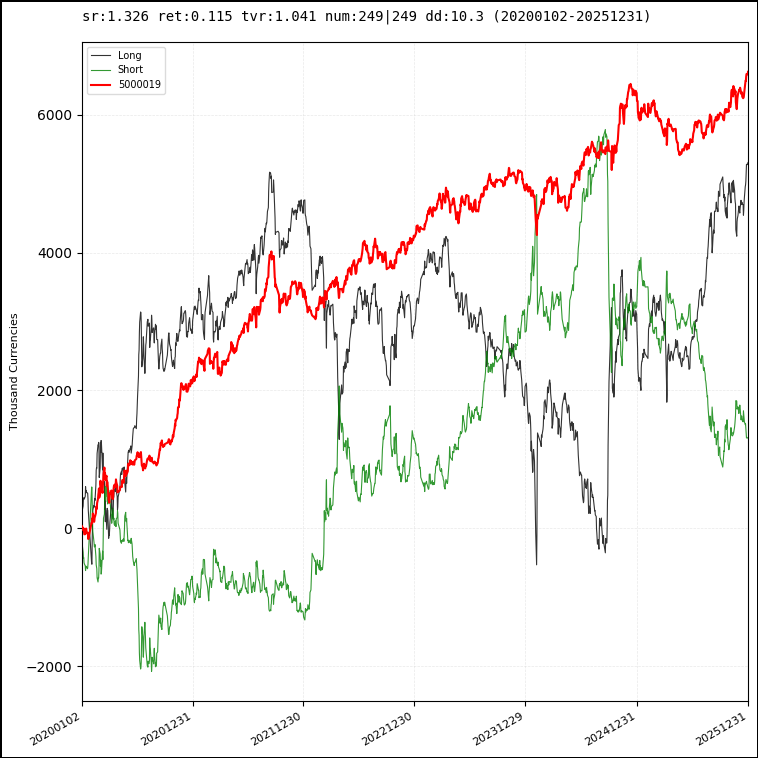

ts_mean(at_mask(vwap-close,cs_rank(at_mask(volume,ts_fill(csi_500_weight)>0))>0.5),2)


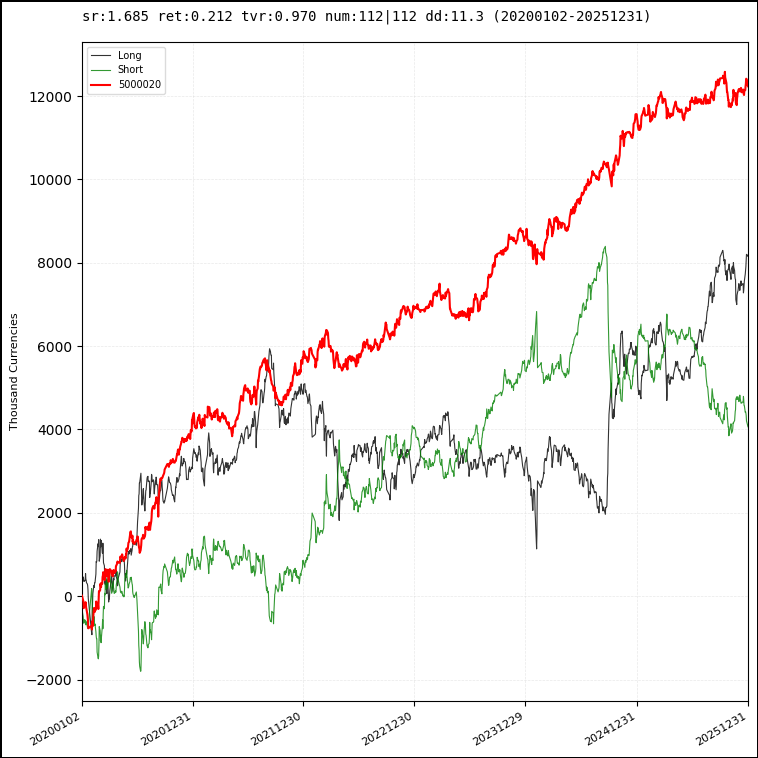

ts_std(low/ts_delay(close,1)-1,100)-ts_std(high/ts_delay(close,1)-1,100)


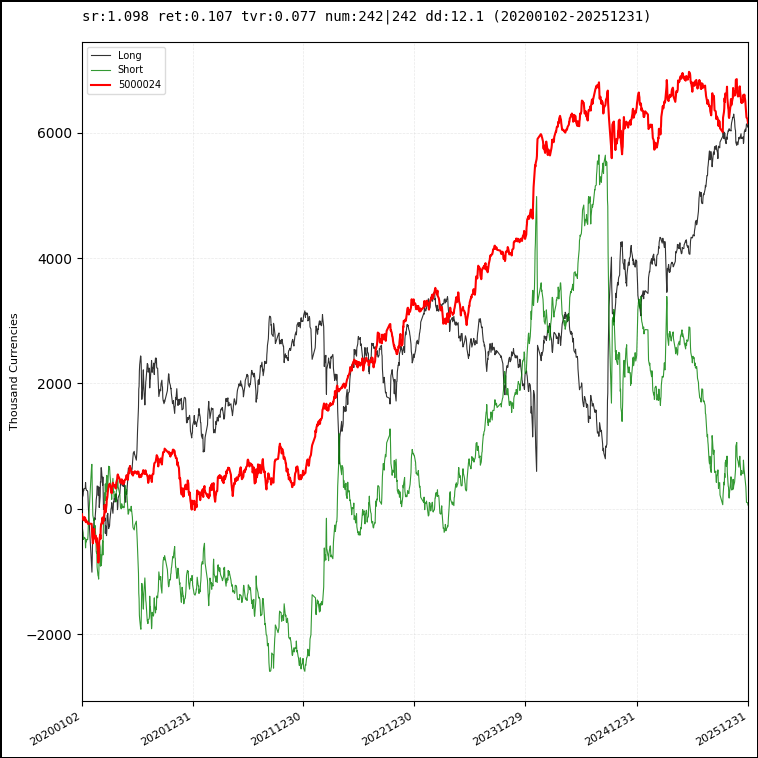

cs_indneut(ts_mean(open-close,2),cs_group_quantile(at_mask(ts_std(close,2),ts_fill(csi_500_weight)>0),50))


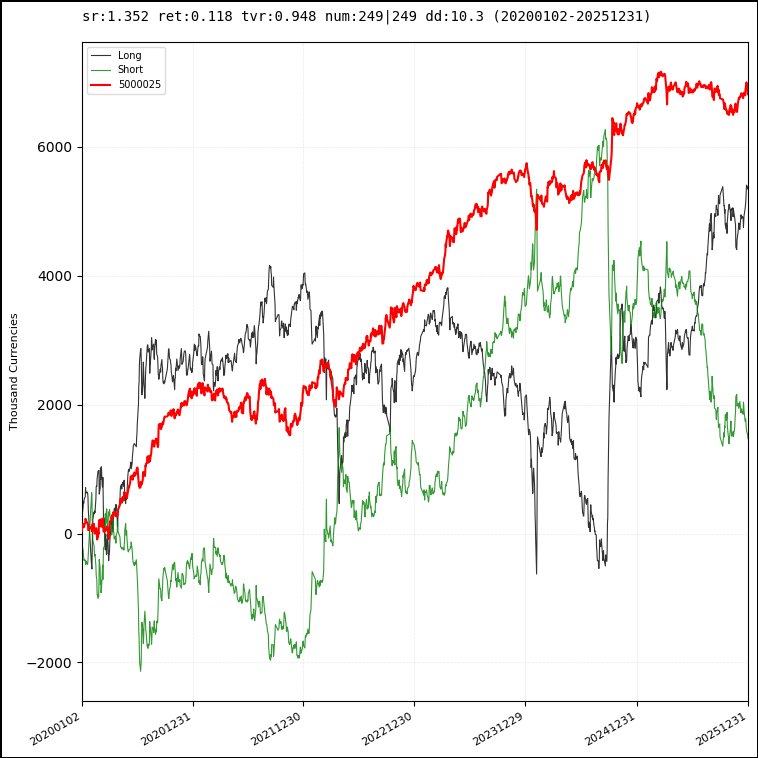

ts_ols(csi_500_ret1,ret1,5)[0]


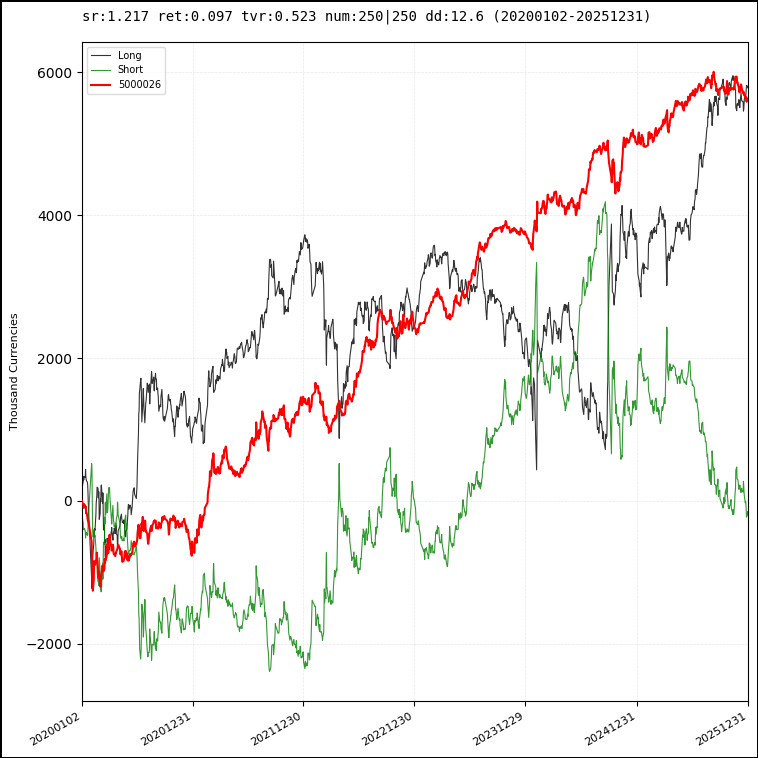

-ts_ols(ret1-csi_500_ret1,ret1,5)[0]


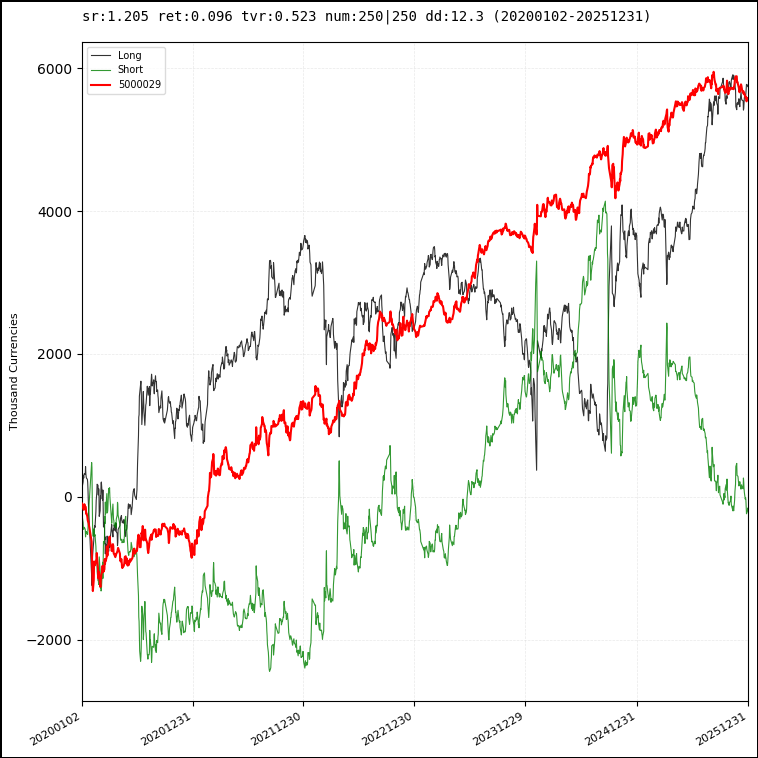

-ts_ols(ts_rank(close,10),ts_rank(np.abs(ret1),10),10)[0]


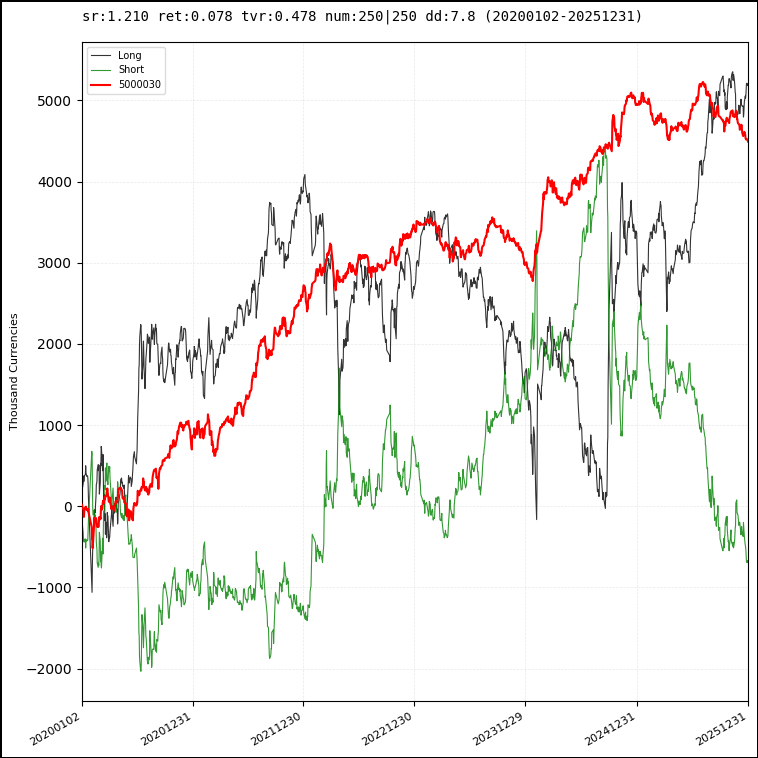

-ts_ols(ts_rank(close,3),ts_rank(vwap,3),3)[2]


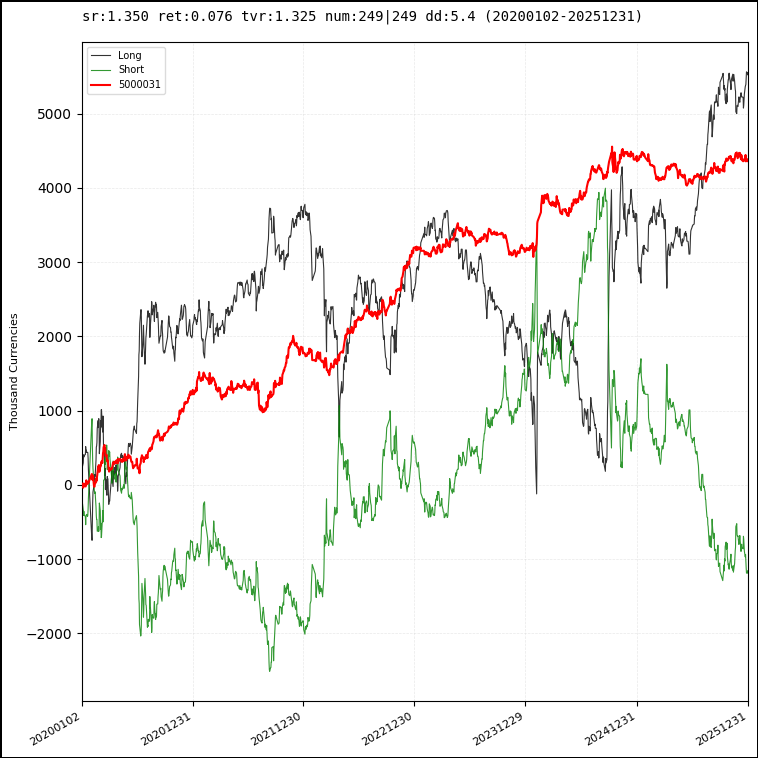

-ts_regression(ts_rank(close,10),ts_rank(ret1,10),10,5)


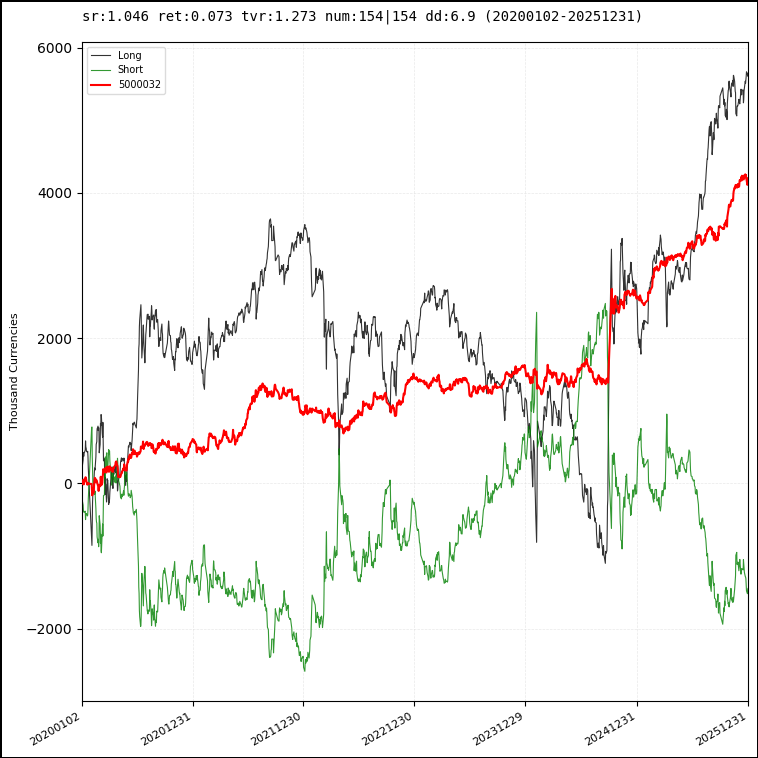

-ts_regression(csi_500_open/ts_delay(csi_500_close,1),close/ts_delay(close,1),10,4)


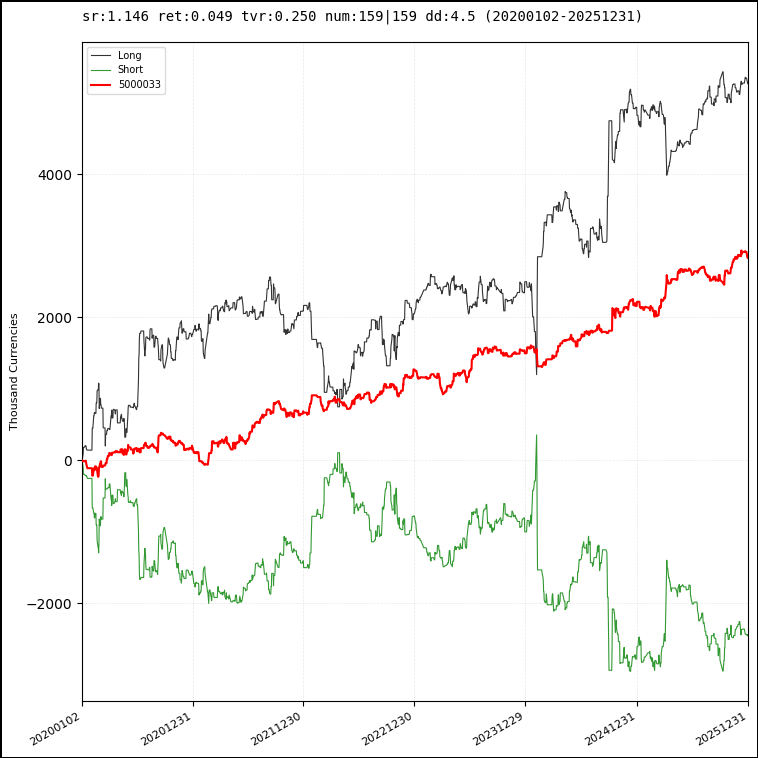

ts_ols(ts_skewness(ret1,5),ret1,5)[0]


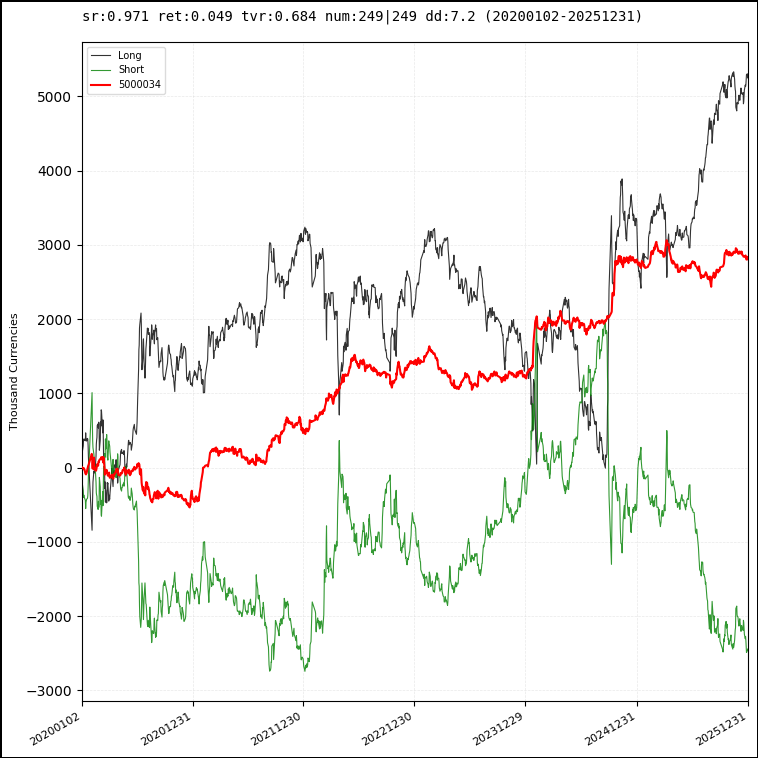

-ts_regression(ts_skewness(ret1,3),ret1,7,9)


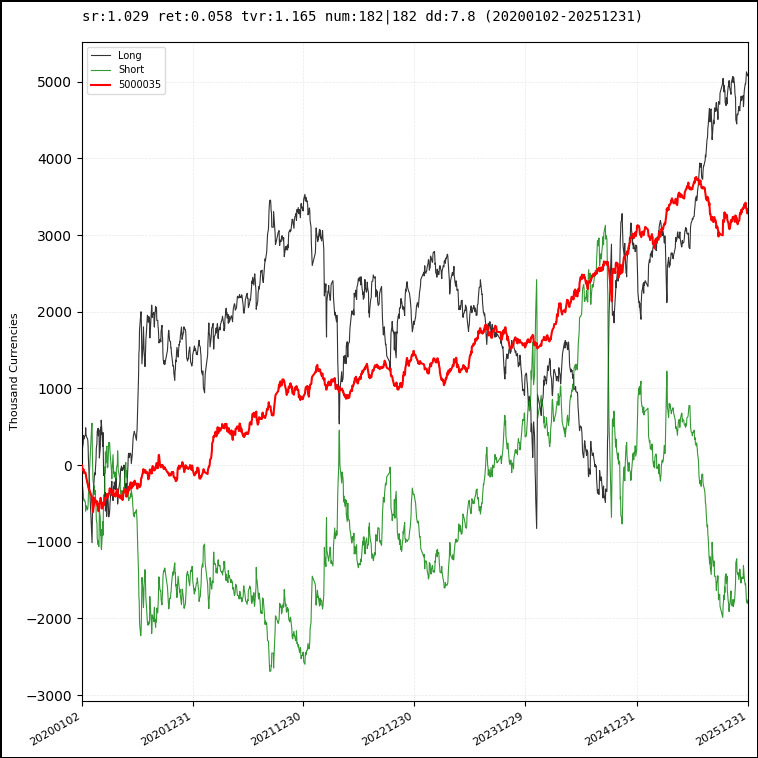

In [8]:
indices=[1,3,4,5,6,9,10,11,12,13,14,19,20,24,25,26,29,30,31,32,33,34,35]
with open ('ruiqiwang_csi_500.txt','r') as f:
    alpha_list=f.read().split('\n')
for i in indices:
    print(alpha_list[i-1])
    executor.simres_cut(executor.alpha_pool[i-1],'20200101','20260101',index=None,save_path=f'../alphas/{enddate}/figpnl/'+executor.alpha_pool[i-1]['alpha_id'])

In [28]:
alpha_matrix=[executor.alpha_matrix[i-1] for i in indices]
combo=op.cs_booksize(np.mean(np.concatenate([item[:,:,None] for item in alpha_matrix],axis=2),axis=2))
weight=op.cs_booksize(op.ts_fill(executor.context['csi_500_weight']))

F:\wangruiqi3\projects\OpenAlpha\src\simres\operators.py:355: RuntimeWarning: invalid value encountered in divide
  long=long/np.nansum(long,axis=0)
F:\wangruiqi3\projects\OpenAlpha\src\simres\operators.py:356: RuntimeWarning: invalid value encountered in divide
  short=short/np.nansum(short,axis=0)


F:\wangruiqi3\projects\OpenAlpha\src\simres\expr.py:189: RuntimeWarning: invalid value encountered in divide
  long_w = pos_mask / np.nansum(pos_mask, axis=0)
F:\wangruiqi3\projects\OpenAlpha\src\simres\expr.py:190: RuntimeWarning: invalid value encountered in divide
  short_w = neg_mask / np.abs(np.nansum(neg_mask, axis=0))


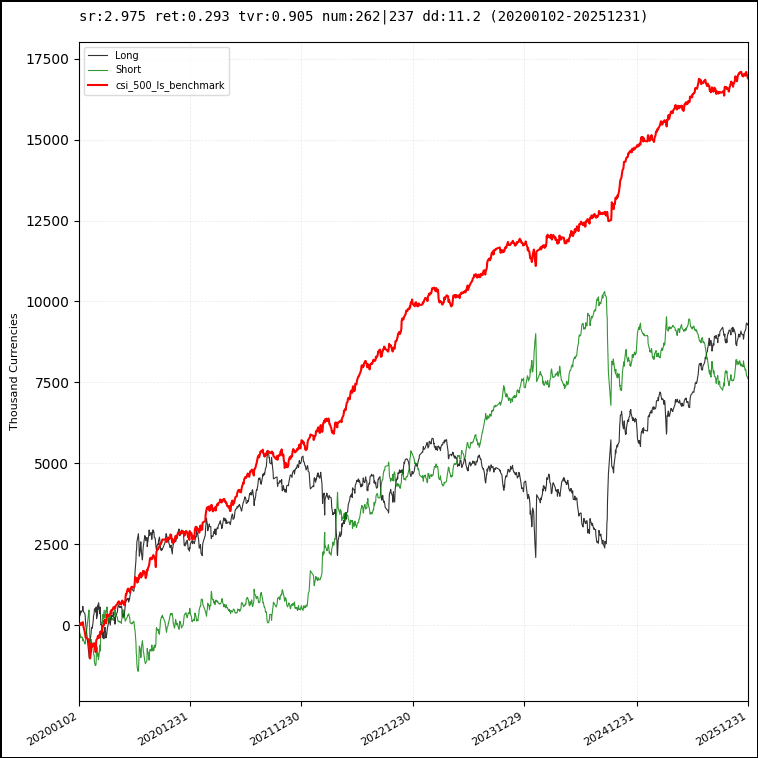

{'ann_ret': np.float32(0.2926106),
 'ann_vol': np.float64(0.09835444654146516),
 'sr': np.float64(2.975062094078108),
 'dd': np.float32(11.219938),
 'tvr_avg': np.float32(0.9048819)}

In [46]:
btresult=executor.backtest(combo,price='vwap')
executor.simres_cut(btresult,'20200101','20260101',index=None,alpha_id='csi_500_ls_benchmark')

In [47]:
# def lo_opt(ls_matrix, index_weight_matrix, offset_limit=0.03):
#     n_stocks,t_days= ls_matrix.shape
#     lo_matrix = np.full((n_stocks,t_days), np.nan)
    
#     w_lo = cp.Variable(n_stocks)
#     w_ls_param = cp.Parameter(n_stocks)
#     w_idx_param = cp.Parameter(n_stocks)
    
#     # 目标函数
#     target_w = w_idx_param + w_ls_param
#     objective = cp.Minimize(cp.sum_squares(w_lo - target_w))

#     # 基础约束
#     base_constraints = [
#         w_lo >= 0,
#         cp.sum(w_lo) == 1,
#         w_lo - w_idx_param <= offset_limit,
#         w_idx_param - w_lo <= offset_limit
#     ]
    
#     for t in tqdm(range(t_days)):
#         curr_ls = np.nan_to_num(ls_matrix[:,t])
#         curr_idx = np.nan_to_num(index_weight_matrix[:,t])
        
#         if np.sum(curr_idx) == 0:
#             continue
            
#         w_ls_param.value = curr_ls
#         w_idx_param.value = curr_idx
        
#         # --- 核心修改：动态增加 Mask 约束 ---
#         # 找出 index_weight <= 0 的索引（即不在成分股里的股票）
#         mask = (curr_idx <= 0)
#         # 增加约束：这些股票的权重强制为 0
#         current_constraints = base_constraints + [w_lo[mask] == 0]
        
#         prob = cp.Problem(objective, current_constraints)
        
#         try:
#             # 提高精度并求解
#             prob.solve(solver=cp.OSQP, warm_start=True, eps_abs=1e-7, eps_rel=1e-7)
            
#             if prob.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
#                 res = w_lo.value
#                 # 针对数值精度问题，进行物理截断和重新归一化
#                 res = np.maximum(res, 0)
#                 res[mask] = 0 # 再次确保 mask 掉的位为 0
                
#                 if np.sum(res) > 0:
#                     lo_matrix[:,t] = res / np.sum(res)
#             else:
#                 # 如果无解，通常是因为成分股太少，offset_limit 限制得太死
#                 # 此时可以 fallback 到指数权重，或者调大偏移
#                 lo_matrix[:,t] = curr_idx 
                
#         except Exception as e:
#             print(f"Error at day {t}: {e}")
            
#     return lo_matrix
# lo_matrix=lo_opt(combo, weight, offset_limit=0.01)

100%|██████████████████████████████████████████████████████████████████████████████| 1455/1455 [02:03<00:00, 11.76it/s]


F:\wangruiqi3\projects\OpenAlpha\src\simres\expr.py:189: RuntimeWarning: invalid value encountered in divide
  long_w = pos_mask / np.nansum(pos_mask, axis=0)
F:\wangruiqi3\projects\OpenAlpha\src\simres\expr.py:190: RuntimeWarning: invalid value encountered in divide
  short_w = neg_mask / np.abs(np.nansum(neg_mask, axis=0))


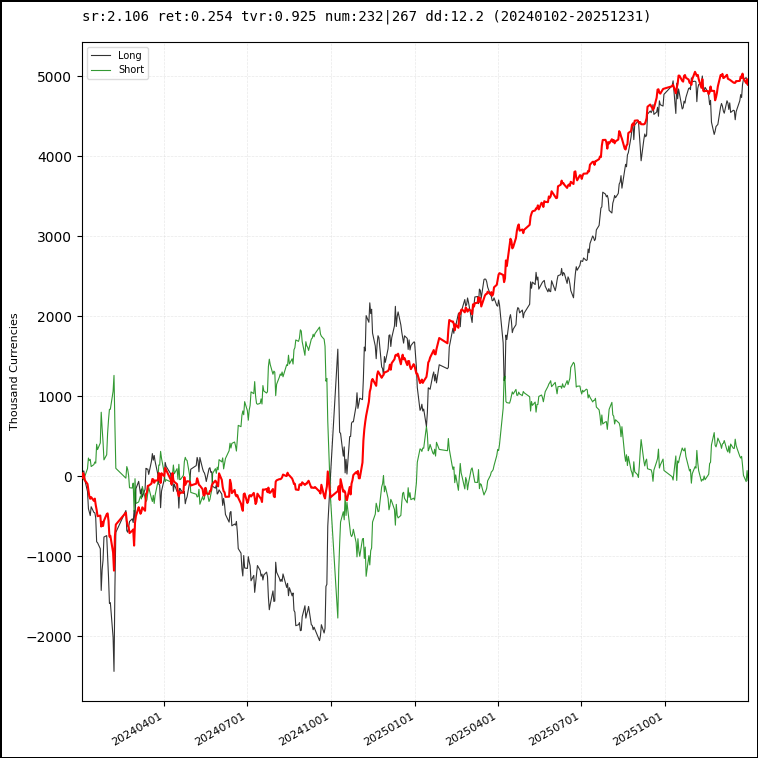

{'ann_ret': np.float32(0.25437075),
 'ann_vol': np.float64(0.12081170538854473),
 'sr': np.float64(2.1055140988089542),
 'dd': np.float32(12.199576),
 'tvr_avg': np.float32(0.9245614)}

In [14]:
btresult=executor.backtest(combo,price='open')
executor.simres_cut(btresult,'20240101','20260101',index=None)